# 2. Preprocesamiento y Visualización de Datos

En este notebook aprenderás técnicas fundamentales de preprocesamiento y visualización de datos usando el dataset Breast Cancer de scikit-learn. Estas técnicas son esenciales para preparar los datos antes de entrenar modelos de Machine Learning.

## Objetivo
- Aprender a explorar, limpiar y transformar datos reales.
- Visualizar relaciones y distribuciones para detectar patrones y problemas.
- Preparar los datos para modelos de Machine Learning.
- Entender y prevenir data leakage con un ejemplo práctico.

## Prerequisitos

> 📌 **Prerequisitos:** Haber completado el [notebook 01 (Introducción a ML)](./01_intro_machine_learning.ipynb).

- Conocimientos básicos de Python, numpy y pandas.
- Conceptos de train/test split (cubiertos en NB01).

## 1. Introducción teórica

El preprocesamiento de datos es el conjunto de técnicas para limpiar, transformar y preparar los datos antes de entrenar modelos. Una buena preparación puede marcar la diferencia entre un modelo mediocre y uno excelente.

### Principales pasos del preprocesamiento:
- Inspección y limpieza de datos faltantes o erróneos.
- Transformación de variables (escalado, normalización, codificación).
- Detección y tratamiento de outliers.
- Selección y reducción de variables.

**Truco:**
- Visualiza siempre tus datos antes y después de cada transformación para evitar errores sutiles.

## 2. Importación de librerías

In [1]:
# === Reproducibilidad ===
import random
import numpy as np
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 3. Carga y exploración del dataset

Usaremos el dataset Breast Cancer de scikit-learn, que contiene características de tumores malignos y benignos.

In [2]:
data = datasets.load_breast_cancer()
X = data.data
y = data.target
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


**Descripción del dataset:**
- 569 muestras, 30 características numéricas.
- Objetivo: clasificar tumores como malignos (0) o benignos (1).

**Truco:**
- Consulta `data.DESCR` para ver la descripción completa del dataset.

In [3]:
print(data.DESCR[:500])  # Mostramos los primeros 500 caracteres

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (


### Análisis exploratorio básico

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


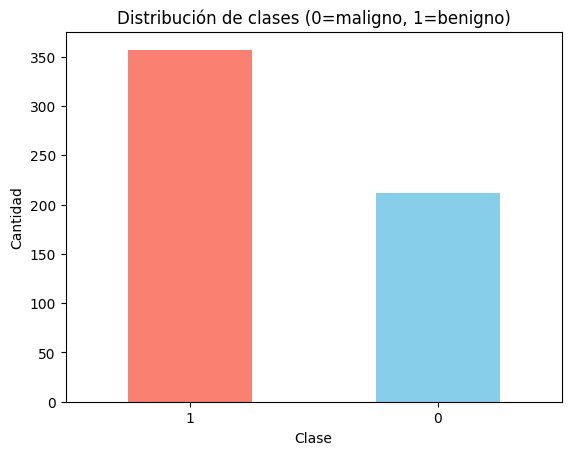

In [6]:
df['target'].value_counts().plot(kind='bar', color=['salmon', 'skyblue'])
plt.title('Distribución de clases (0=maligno, 1=benigno)')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.show()

**¿Qué buscar en la exploración inicial?**
- ¿Hay datos faltantes o valores atípicos?
- ¿Las clases están balanceadas?
- ¿Qué variables tienen mayor varianza o valores extremos?

**Truco:**
- Usa `df.isnull().sum()` para buscar valores nulos rápidamente.

In [7]:
# Revisión de valores nulos
print('Valores nulos por columna:')
print(df.isnull().sum().sum(), 'valores nulos en total')

Valores nulos por columna:
0 valores nulos en total


### Visualización de outliers y distribución de variables

Los outliers pueden afectar negativamente a los modelos. Es importante detectarlos y decidir si deben tratarse.

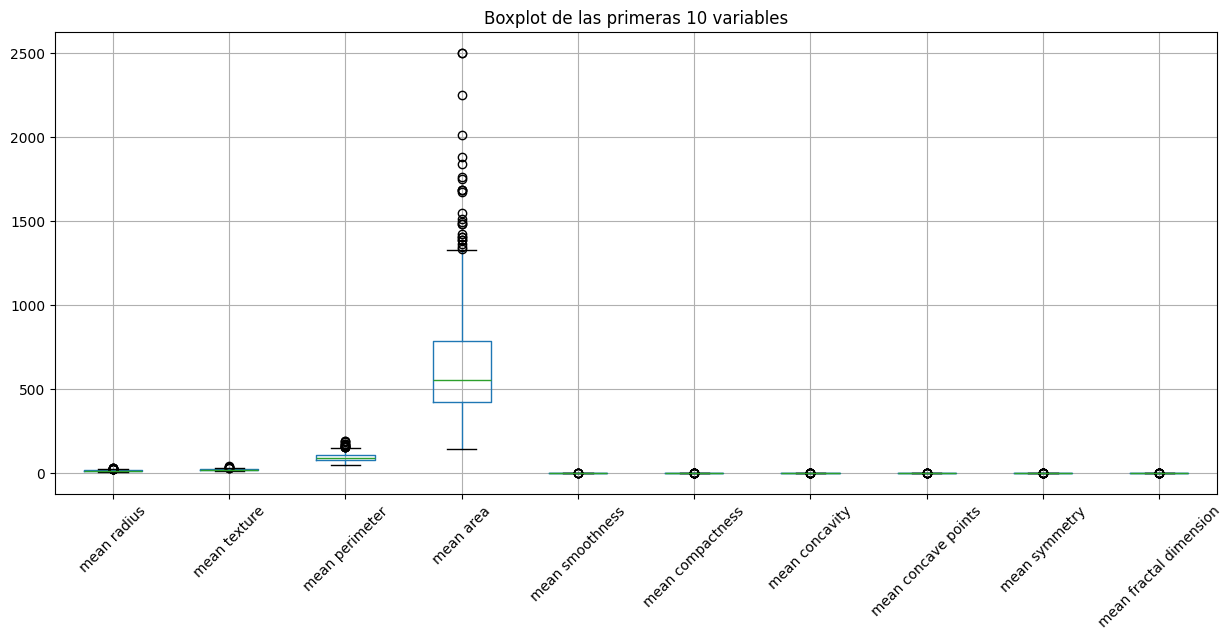

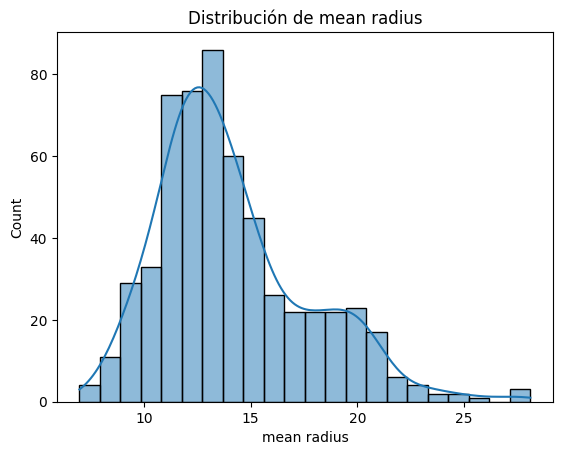

In [8]:
# Boxplot de las primeras 10 variables
plt.figure(figsize=(15,6))
df.iloc[:,:10].boxplot(rot=45)
plt.title('Boxplot de las primeras 10 variables')
plt.show()

# Histograma de una variable ejemplo
sns.histplot(df['mean radius'], kde=True)
plt.title('Distribución de mean radius')
plt.show()

**¿Qué hacer con los outliers?**
- Analizarlos individualmente: pueden ser errores de medición o casos reales.
- Opciones: eliminarlos, imputarlos, o usar modelos robustos (como `RobustScaler`).

**Truco:**
- Usa `RobustScaler` para reducir el impacto de outliers en el escalado.

### Ingeniería de variables y codificación

Aunque este dataset es numérico, es importante conocer técnicas para transformar variables categóricas y crear nuevas variables útiles.

In [9]:
# Ejemplo de creación de variable binaria artificial
df['large_radius'] = (df['mean radius'] > df['mean radius'].median()).astype(int)
df[['mean radius', 'large_radius']].head()

,mean radius,large_radius
0,17.99,1
1,20.57,1
2,19.69,1
3,11.42,0
4,20.29,1


**¿Qué técnicas existen para variables categóricas?**
- One-hot encoding (`pd.get_dummies`)
- Label encoding (`sklearn.preprocessing.LabelEncoder`)
- Target encoding (codificación por media de la variable objetivo)

**Truco:**
- Para variables ordinales, usa `OrdinalEncoder` para mantener el orden.

## 4. Escalado y normalización de variables

El escalado es fundamental para algoritmos sensibles a la magnitud de las variables (regresión logística, SVM, redes neuronales, etc.).

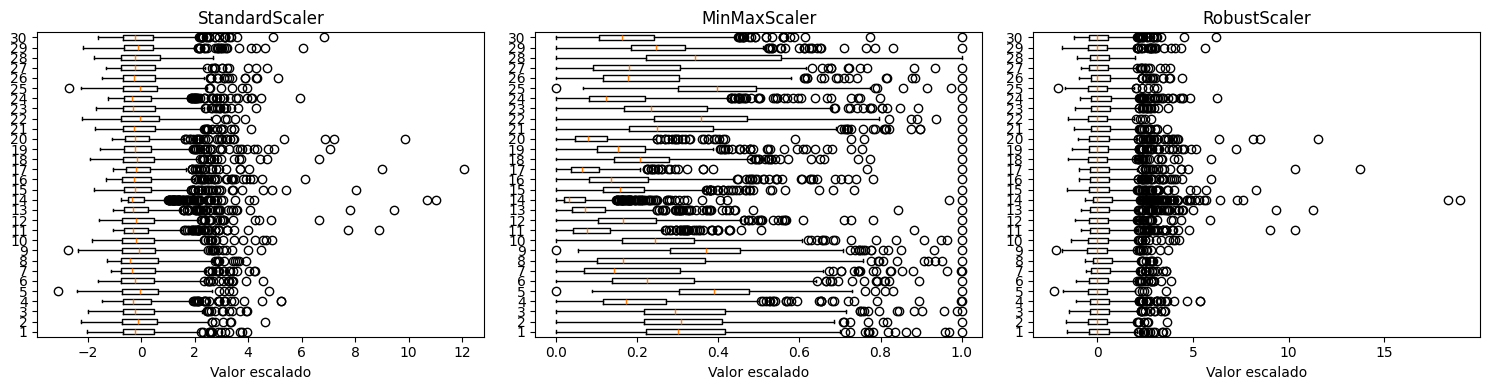

In [10]:
# Comparación de escaladores
escaladores = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

plt.figure(figsize=(15,4))
for i, (nombre, scaler) in enumerate(escaladores.items(), 1):
    X_scaled = scaler.fit_transform(df.iloc[:,:30])
    plt.subplot(1,3,i)
    plt.boxplot(X_scaled, vert=False)
    plt.title(nombre)
    plt.xlabel('Valor escalado')
plt.tight_layout()
plt.show()

**¿Cuál usar?**
- `StandardScaler`: media 0, varianza 1. Útil para la mayoría de modelos.
- `MinMaxScaler`: escala entre 0 y 1. Útil para redes neuronales.
- `RobustScaler`: usa mediana y percentiles, robusto a outliers.

**Truco:**
- Escala siempre **después** de dividir en train/test para evitar data leakage.

### ⚠️ Data Leakage: ejemplo práctico

**Data leakage** ocurre cuando se usa información del conjunto de test durante el entrenamiento. Un error común es escalar **antes** de dividir los datos. Veamos la diferencia:

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# === INCORRECTO: escalar ANTES de dividir (data leakage) ===
scaler_mal = StandardScaler()
X_scaled_mal = scaler_mal.fit_transform(X)  # ¡Usa TODOS los datos para escalar!
X_train_mal, X_test_mal, y_train_mal, y_test_mal = train_test_split(
    X_scaled_mal, y, test_size=0.2, random_state=SEED)
clf_mal = LogisticRegression(max_iter=200, random_state=SEED)
clf_mal.fit(X_train_mal, y_train_mal)
acc_mal = accuracy_score(y_test_mal, clf_mal.predict(X_test_mal))

# === CORRECTO: dividir ANTES de escalar ===
X_train_ok, X_test_ok, y_train_ok, y_test_ok = train_test_split(
    X, y, test_size=0.2, random_state=SEED)
scaler_ok = StandardScaler()
X_train_ok_s = scaler_ok.fit_transform(X_train_ok)  # Solo fit en train
X_test_ok_s = scaler_ok.transform(X_test_ok)         # Solo transform en test
clf_ok = LogisticRegression(max_iter=200, random_state=SEED)
clf_ok.fit(X_train_ok_s, y_train_ok)
acc_ok = accuracy_score(y_test_ok, clf_ok.predict(X_test_ok_s))

print(f'Accuracy CON data leakage:  {acc_mal:.4f}')
print(f'Accuracy SIN data leakage: {acc_ok:.4f}')
print(f'\n💡 En datasets pequeños la diferencia puede ser mínima, pero en datos'
      f'\n   reales con distribuciones sesgadas puede inflar el accuracy artificialmente.')

Accuracy CON data leakage:  0.9737
Accuracy SIN data leakage: 0.9737

💡 En datasets pequeños la diferencia puede ser mínima, pero en datos
   reales con distribuciones sesgadas puede inflar el accuracy artificialmente.


**¿Cómo evitar data leakage?**
- Usa `Pipeline` de scikit-learn (ver [NB01](./01_intro_machine_learning.ipynb)).
- Divide **siempre** antes de cualquier transformación que use estadísticas de los datos.
- Revisa que `fit_transform` se use solo en train y `transform` solo en test.

## 5. Reducción de dimensionalidad (PCA)

La reducción de dimensionalidad ayuda a visualizar datos complejos y a eliminar ruido o redundancia.

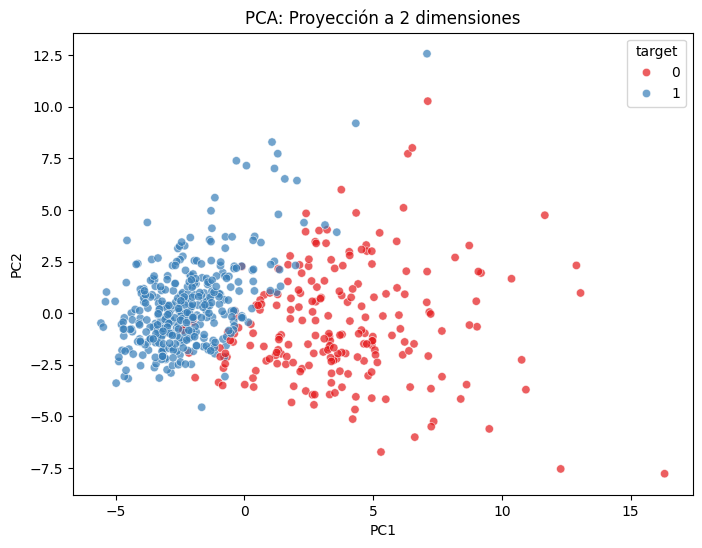

Varianza explicada por PC1 y PC2: [0.44272026 0.18971182]
Varianza total explicada: 63.24%


In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.iloc[:,:30])
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['target'], palette='Set1', alpha=0.7)
plt.title('PCA: Proyección a 2 dimensiones')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

print('Varianza explicada por PC1 y PC2:', pca.explained_variance_ratio_)
print(f'Varianza total explicada: {sum(pca.explained_variance_ratio_):.2%}')

**¿Cuándo usar PCA?**
- Para visualizar datos de alta dimensión.
- Para eliminar variables redundantes o ruido.
- Antes de modelos sensibles a la multicolinealidad.

**Truco:**
- Ajusta `n_components` para retener el 95% de la varianza.

## 6. Visualización de correlaciones

Las correlaciones ayudan a detectar variables redundantes y relaciones interesantes.

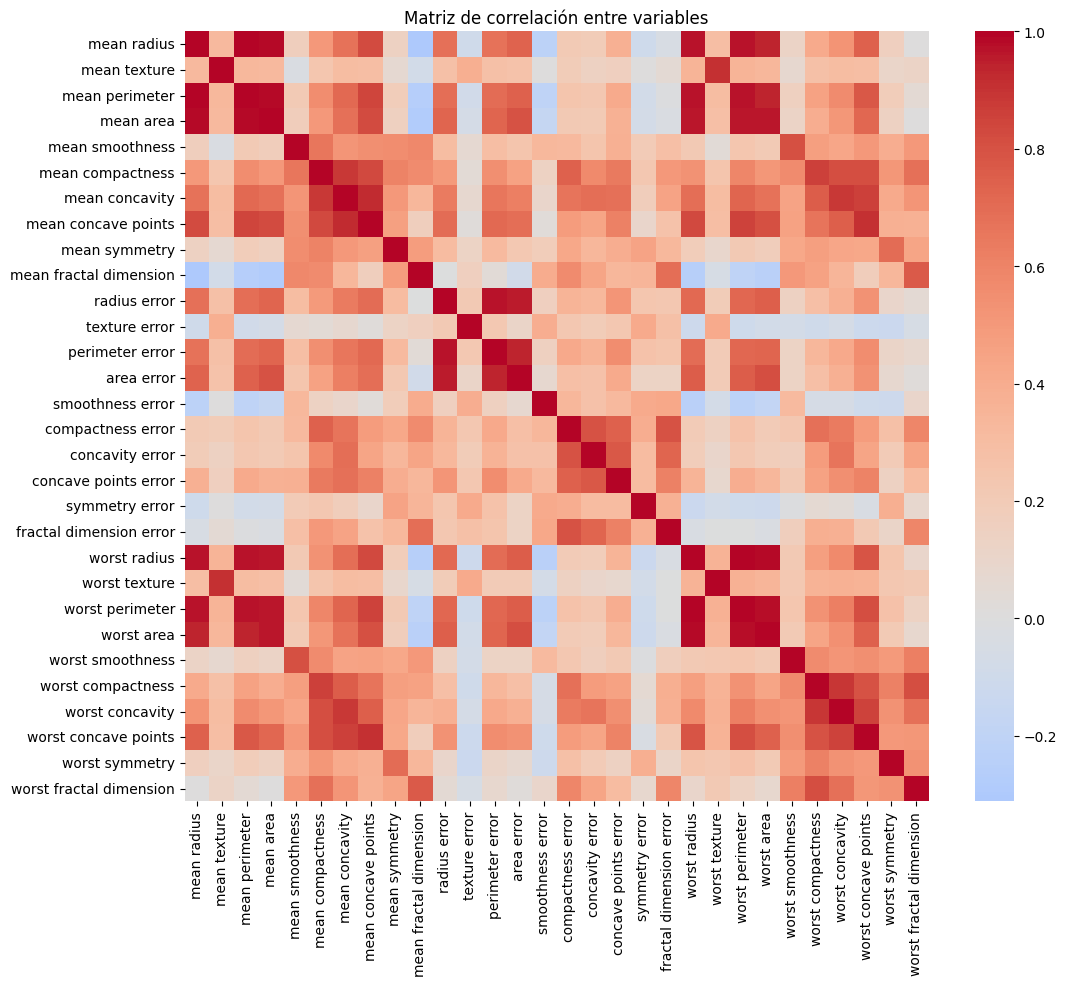

In [13]:
plt.figure(figsize=(12,10))
sns.heatmap(df.iloc[:,:30].corr(), cmap='coolwarm', center=0)
plt.title('Matriz de correlación entre variables')
plt.show()

**¿Qué hacer con variables altamente correlacionadas?**
- Eliminar una de ellas para evitar redundancia.
- Usar PCA para combinarlas en componentes principales.

**Truco:**
- Elimina variables con correlación > 0.95 para modelos lineales.

## 7. Selección de variables

Seleccionar las variables más relevantes puede mejorar el desempeño y la interpretabilidad del modelo.

Variables seleccionadas: ['mean perimeter' 'mean concave points' 'worst radius' 'worst perimeter'
 'worst concave points']


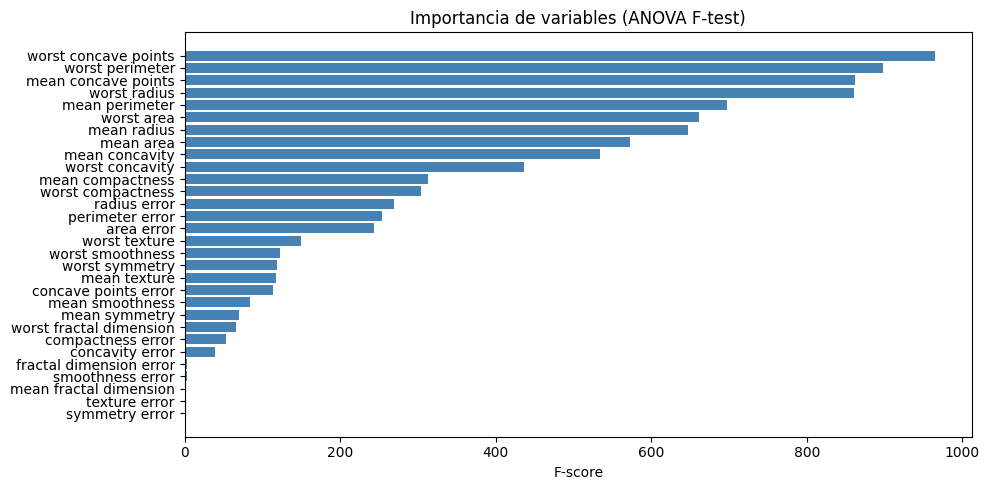

In [14]:
from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(score_func=f_classif, k=5)
X_new = selector.fit_transform(X, y)
selected_features = np.array(data.feature_names)[selector.get_support()]
print('Variables seleccionadas:', selected_features)

# Visualizar los scores de cada variable
scores_feat = pd.DataFrame({'feature': data.feature_names, 'score': selector.scores_})
scores_feat = scores_feat.sort_values('score', ascending=False)
plt.figure(figsize=(10,5))
plt.barh(scores_feat['feature'], scores_feat['score'], color='steelblue')
plt.xlabel('F-score')
plt.title('Importancia de variables (ANOVA F-test)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**¿Qué métodos existen?**
- `SelectKBest`: selecciona las mejores variables según una métrica estadística.
- `RFE`: elimina recursivamente variables menos importantes.
- Modelos con regularización L1 (Lasso).

**Truco:**
- Usa selección de variables junto con validación cruzada para evitar sobreajuste.

## 8. Discusión y Conclusiones

- El preprocesamiento y la visualización son pasos críticos antes de modelar.
- Escala, selecciona y transforma tus variables según el modelo y el problema.
- Visualiza siempre los efectos de cada transformación.
- **Evita data leakage**: divide antes de escalar y usa Pipeline.
- Documenta cada decisión de preprocesamiento para reproducibilidad.

## 9. Ejercicios Propuestos

1. **Ejercicio 1:** Agrega ruido artificial a 3 columnas del dataset y usa un Denoising approach para limpiarlas. ¿Cambian las correlaciones?

2. **Ejercicio 2:** Aplica PCA reteniendo el 95% de la varianza. ¿Cuántos componentes necesitas? Entrena un modelo de clasificación con los componentes reducidos y compara con el accuracy usando todas las variables.

3. **Ejercicio 3:** Compara los 3 escaladores (`StandardScaler`, `MinMaxScaler`, `RobustScaler`) combinados con LogisticRegression usando validación cruzada. ¿Cuál da mejor resultado en este dataset?

4. **Ejercicio 4 (Avanzado):** Implementa un pipeline que combine `SelectKBest` + `StandardScaler` + `LogisticRegression` y optimiza `k` (número de variables) con `GridSearchCV`.

## 10. Referencias y Recursos

- [Documentación de scikit-learn: Preprocessing](https://scikit-learn.org/stable/modules/preprocessing.html)
- [Feature Selection - scikit-learn](https://scikit-learn.org/stable/modules/feature_selection.html)
- [Data Leakage in ML - Kaggle](https://www.kaggle.com/code/alexisbcook/data-leakage)
- [Feature Engineering - Towards Data Science](https://towardsdatascience.com/feature-engineering-for-machine-learning-3a5e293a5114)

---

📎 **Notebook anterior:** [01. Introducción a ML](./01_intro_machine_learning.ipynb)  
📎 **Notebook siguiente:** [03. Modelos Clásicos de ML](./03_modelos_clasicos_ml.ipynb)